# Replay analysis — one Kaggle episode

Parses replay JSON from `kaggle_logs/<submission_id>/replays/` (both players' private state + actions).

Batch summary for all episodes in a submission:

```bash
scripts/summarize_replays.sh <submission_id> --us-name "Your Name"
# writes kaggle_logs/<submission_id>/<submission_id>.json

cd scripts && python -m replay_analysis ../kaggle_logs/<submission_id> --us-name "Your Name"
```

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from replay_analysis import analyze, plot_game

SUBMISSION_ID = "55934103"
EPISODE_ID = "104511803"  # from episodes.csv or replay filename
US_NAME = "Milos Vlainic"  # optional; matches info.TeamNames

REPLAY = ROOT / f"kaggle_logs/{SUBMISSION_ID}/replays/episode-{EPISODE_ID}-replay.json"
print(REPLAY, REPLAY.exists())

/media/wlaki/W/DS_projects/Kaggle/kaggriculture/kaggle_logs/55934103/replays/episode-104511803-replay.json True


In [3]:
report = analyze(REPLAY, us_name=US_NAME)
print(
    f"episode={report['episode_id']} seed={report['seed']} "
    f"rewards={report['rewards']} us_index={report['us_index']}"
)
us = report["us_index"] or 0
print(f"PASS total: {report['passes']['by_player'][us]['total']}")
print(f"Sold (filled): {report['sells']['by_player'][us]['filled_units']}")
print(f"End shed: {report['shed_end']['by_player'][us]['combined']}")

episode=104511803 seed=333878077 rewards=[30269.0, 80797.0] us_index=1
PASS total: 722
Sold (filled): {'WHEAT': 75, 'FERTILIZER': 157, 'CARROT': 35, 'EGG': 188, 'TOMATO': 13, 'MILK': 104, 'MELON': 18, 'WOOL': 22, 'STRAWBERRY': 84}
End shed: {'FERTILIZER': 2, 'MILK': 3, 'WHEAT': 6, 'CARROT': 9, 'EGG': 2}


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/replay_analysis/plot.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


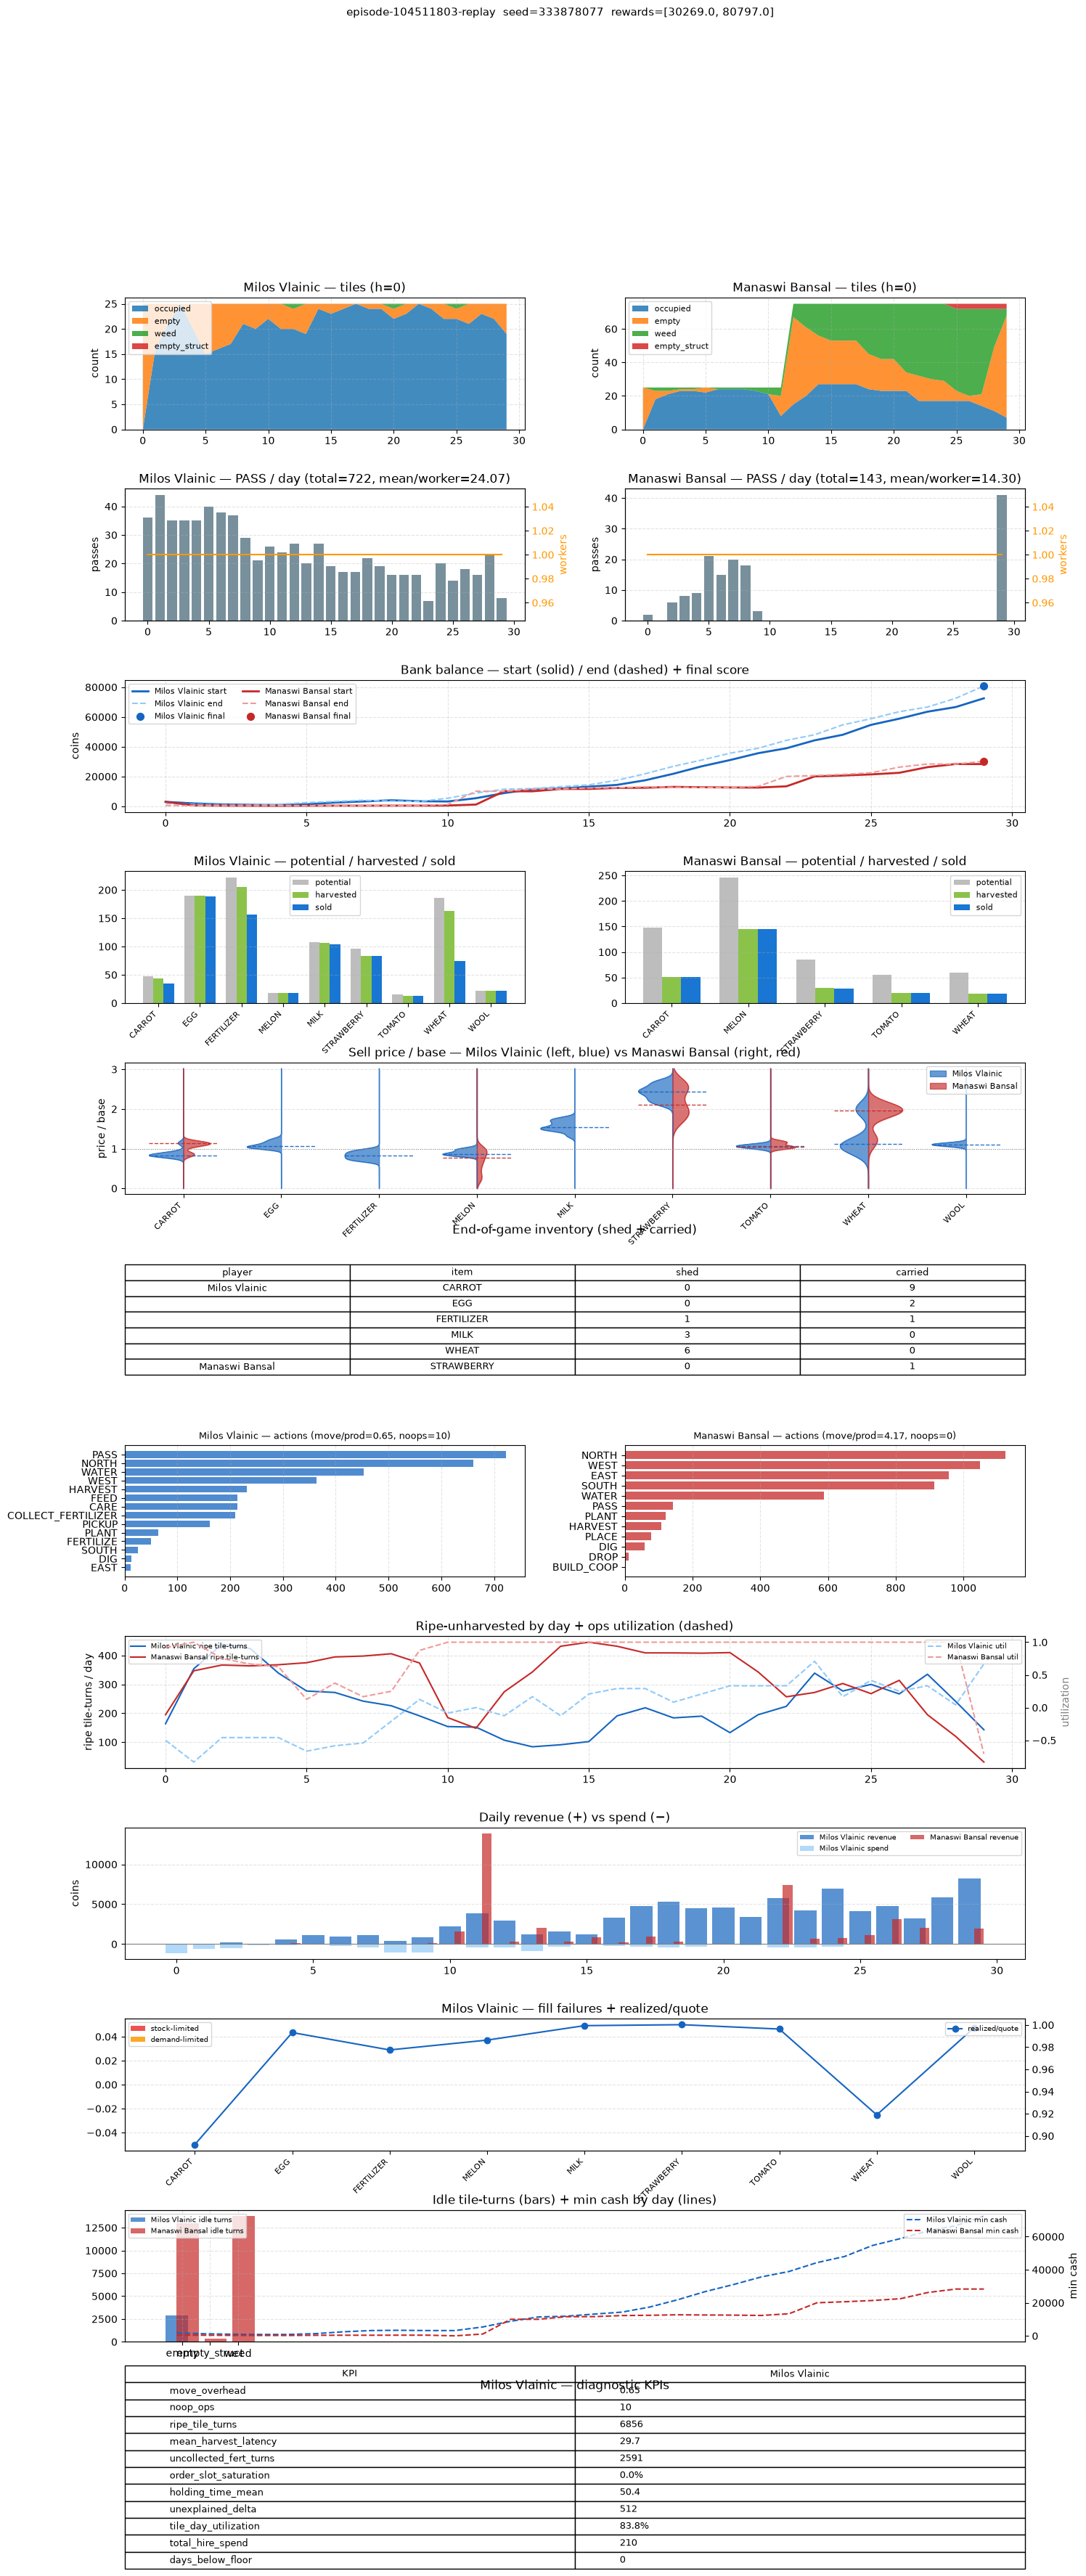

In [4]:
plot_game(report)